In [135]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.2f}'.format)

In [136]:
df_customer = pd.read_csv('/content/QVI_purchase_behaviour.csv')

In [137]:
df_customer

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [138]:
df_customer.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [139]:
df_customer.duplicated().sum()

np.int64(0)

In [140]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


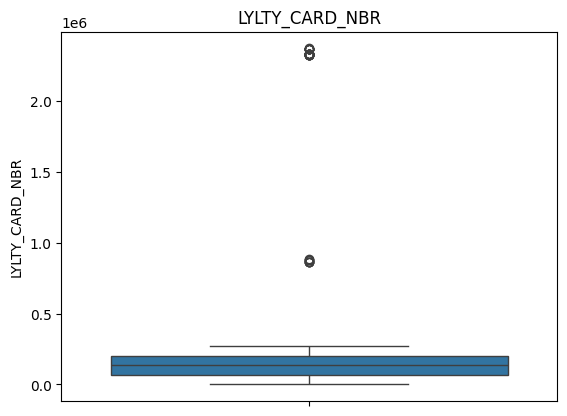

In [141]:
for col in df_customer.columns:
  if df_customer[col].dtype == 'int64' or df_customer[col].dtype == 'float64':
    sns.boxplot(df_customer[col])
    plt.title(col)
    plt.show()

In [142]:
df_customer = df_customer[df_customer['LYLTY_CARD_NBR'] < 500000]

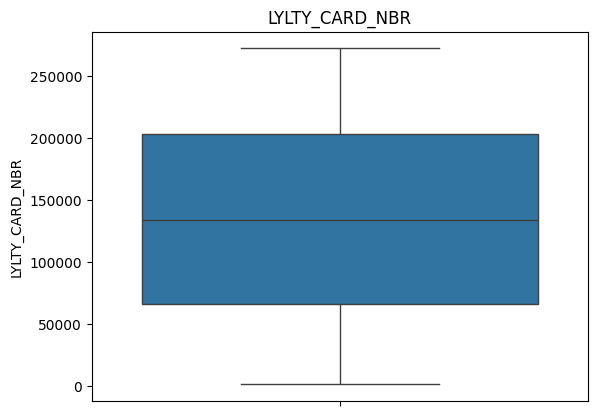

In [143]:
for col in df_customer.columns:
  if df_customer[col].dtype == 'int64' or df_customer[col].dtype == 'float64':
    sns.boxplot(df_customer[col])
    plt.title(col)
    plt.show()

In [144]:
df_transaction = pd.read_excel('/content/QVI_transaction_data.xlsx')

In [145]:
df_transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80


In [146]:
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [147]:
df_transaction['DATE'] = pd.to_datetime(df_transaction['DATE'], unit='D', origin='1899-12-30')

In [148]:
df_transaction = df_transaction[df_transaction['PROD_NAME'].str.contains('Chips', case=False)]

In [149]:
df_transaction['PACK_SIZE'] = df_transaction['PROD_NAME'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2430/3182135154.py:1: SyntaxWarning: invalid escape sequence '\d'
  df_transaction['PACK_SIZE'] = df_transaction['PROD_NAME'].str.extract('(\d+)').astype(int)


In [150]:
df_transaction['BRAND'] = df_transaction['PROD_NAME'].str.split().str[0]

In [151]:
df_transaction.isnull().sum().sum()

np.int64(0)

In [152]:
df_transaction.duplicated().sum()

np.int64(0)

In [153]:
df_transaction.drop_duplicates(inplace=True)

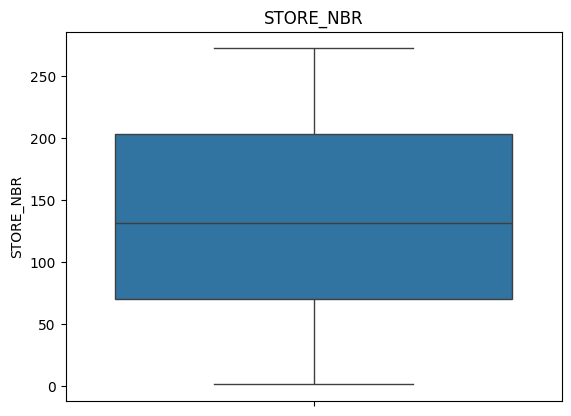

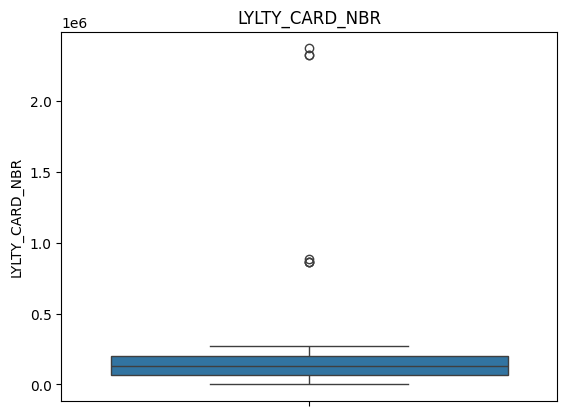

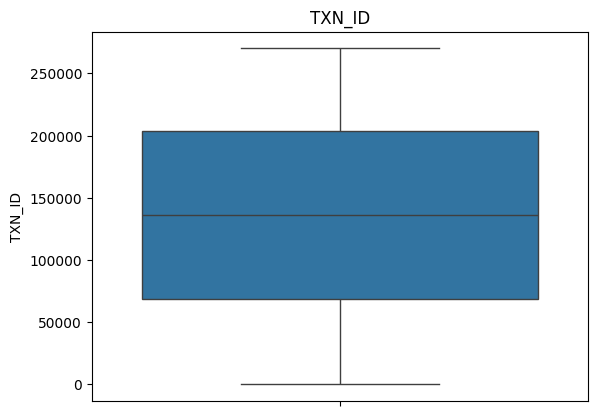

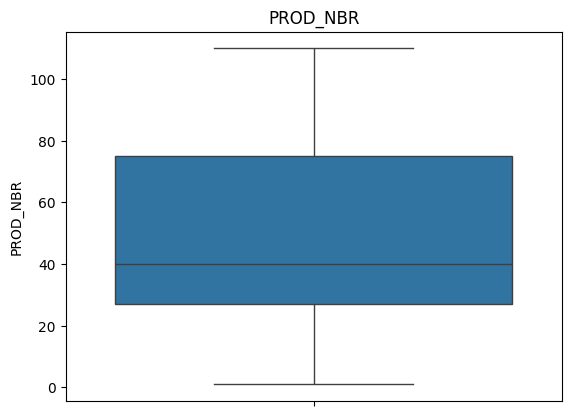

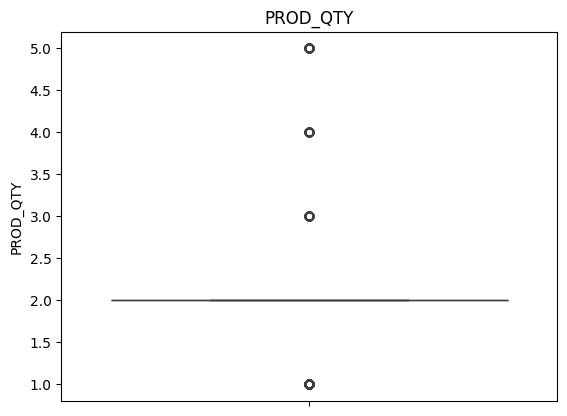

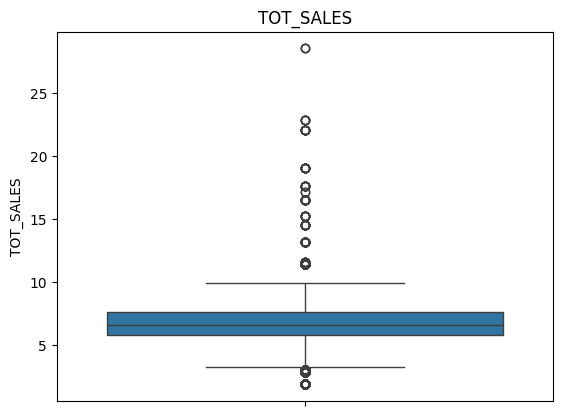

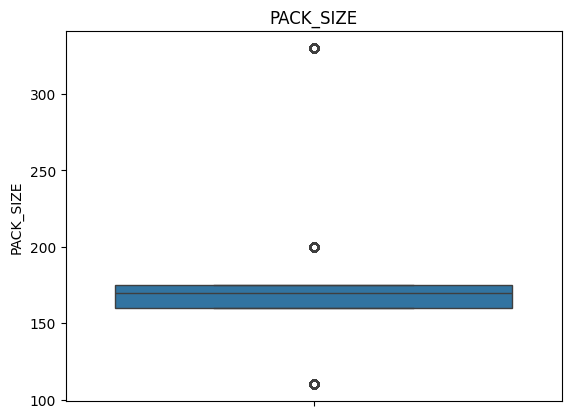

In [154]:
for col in df_transaction.columns:
  if df_transaction[col].dtype == 'int64' or df_transaction[col].dtype == 'float64':
    sns.boxplot(df_transaction[col])
    plt.title(col)
    plt.show()

In [155]:
df_transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,49770,49770.00,49770.00,49770.00,49770.00,49770.00,49770.00,49770.00
mean,2018-12-30 04:52:46.437612800,135.69,136056.92,135763.23,44.16,1.91,6.75,171.36
min,2018-07-01 00:00:00,1.00,1004.00,5.00,1.00,1.00,1.90,110.00
25%,2018-09-30 00:00:00,70.00,70176.25,68503.50,27.00,2.00,5.80,160.00
50%,2018-12-30 00:00:00,131.00,132217.50,135896.00,40.00,2.00,6.60,170.00
75%,2019-03-31 00:00:00,203.00,203262.00,203381.50,75.00,2.00,7.60,175.00
max,2019-06-30 00:00:00,272.00,2373711.00,270209.00,110.00,5.00,28.50,330.00
std,NaN,76.76,78918.55,77969.63,29.28,0.34,2.16,49.11


In [156]:
df_transaction = df_transaction[df_transaction['LYLTY_CARD_NBR'] < 500000]
df_transaction = df_transaction[df_transaction['PROD_QTY'] < 10]

In [157]:
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49763 entries, 2 to 264830
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATE            49763 non-null  datetime64[ns]
 1   STORE_NBR       49763 non-null  int64         
 2   LYLTY_CARD_NBR  49763 non-null  int64         
 3   TXN_ID          49763 non-null  int64         
 4   PROD_NBR        49763 non-null  int64         
 5   PROD_NAME       49763 non-null  object        
 6   PROD_QTY        49763 non-null  int64         
 7   TOT_SALES       49763 non-null  float64       
 8   PACK_SIZE       49763 non-null  int64         
 9   BRAND           49763 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 4.2+ MB


In [160]:
df_transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,170,Smiths
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.70,330,Smiths
10,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.70,330,Smiths
14,2019-05-15,19,19272,16686,44,Thins Chips Light& Tangy 175g,1,3.30,175,Thins
33,2019-05-18,45,45220,41651,22,Thins Chips Originl saltd 175g,1,3.30,175,Thins


In [158]:
df_combined = pd.merge(df_transaction, df_customer, on='LYLTY_CARD_NBR', how='left')

In [159]:
df_combined

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
1,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.70,330,Smiths,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.70,330,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2019-05-15,19,19272,16686,44,Thins Chips Light& Tangy 175g,1,3.30,175,Thins,MIDAGE SINGLES/COUPLES,Budget
4,2019-05-18,45,45220,41651,22,Thins Chips Originl saltd 175g,1,3.30,175,Thins,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
49758,2018-08-24,271,271051,268506,47,Doritos Corn Chips Original 170g,2,8.80,170,Doritos,YOUNG SINGLES/COUPLES,Premium
49759,2018-11-04,271,271193,269365,33,Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,2,7.60,110,Cobs,YOUNG SINGLES/COUPLES,Premium
49760,2019-05-29,271,271193,269366,75,Cobs Popd Sea Salt Chips 110g,2,7.60,110,Cobs,YOUNG SINGLES/COUPLES,Premium
49761,2019-03-25,272,272194,269908,75,Cobs Popd Sea Salt Chips 110g,2,7.60,110,Cobs,YOUNG SINGLES/COUPLES,Premium
